# Pearson Correlation Coefficient

The **Pearson correlation coefficient**, denoted by $r$, measures the **strength** and **direction** of the **linear relationship** between two variables $X$ and $Y$.

Its value satisfies:

$$
-1 \le r \le 1
$$

- $r = 1$: perfect positive linear correlation  
- $r = -1$: perfect negative linear correlation  
- $r = 0$: no linear correlation  


## 1. Population Formula

The population Pearson correlation is:

$$
\rho_{X,Y} = 
\frac{\operatorname{Cov}(X,Y)}
{\sigma_X \, \sigma_Y}
$$

Where:

- $\operatorname{Cov}(X,Y)$ is the covariance  
- $\sigma_X$ and $\sigma_Y$ are the standard deviations of $X$ and $Y$


## 2. Sample Pearson Correlation Formula

Given paired observations $(x_1, y_1), \ldots, (x_n, y_n)$, the sample correlation is:

$$
r = 
\frac{
\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})
}{
\sqrt{
\sum_{i=1}^n (x_i - \bar{x})^2
\sum_{i=1}^n (y_i - \bar{y})^2
}
}
$$

Where:

- $\bar{x} = \frac{1}{n}\sum x_i$  
- $\bar{y} = \frac{1}{n}\sum y_i$


## 3. Interpretation

Pearson correlation is essentially a **standardized covariance**:

$$
r = \frac{\text{covariance}}{\text{product of standard deviations}}
$$

Interpretation:

- If $X$ and $Y$ increase together → covariance > 0 → $r > 0$  
- If one increases while the other decreases → covariance < 0 → $r < 0$  
- If they move independently → covariance $\approx 0$ → $r \approx 0$


## 4. Assumptions

Pearson’s correlation assumes:

- **Linearity** between the variables  
- **Continuous numeric variables**  
- **No extreme outliers**  
- **Approximately normal distribution** (important for statistical inference about population)

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns


##### Manually

In [2]:
x = [5, 11, 21, 30]

In [3]:
y = [8, 17, 24, 33]

In [4]:
mean_x = np.mean(x)

In [5]:
print(mean_x)

16.75


In [6]:
mean_y = np.mean(y)

In [7]:
print(mean_y)

20.5


In [8]:
numerator = np.sum((x - mean_x)*(y - mean_y))

In [9]:
denominator = np.sqrt(np.sum((x - mean_x)**2) * np.sum((y - mean_y)**2))

In [10]:
r = numerator / denominator

In [11]:
print(r)

0.9911564424693111


##### Numpy

In [12]:
r_numpy = np.corrcoef(x, y)[0, 1]

In [13]:
print(r_numpy)

0.9911564424693111


##### Scipy

In [14]:
r_scipy, p_value = pearsonr(x, y)

In [15]:
print(r_scipy)

0.9911564424693112


##### Pandas

In [17]:
data = {'x': x,
        'y': y}

df = pd.DataFrame(data)
df

,x,y
0,5,8
1,11,17
2,21,24
3,30,33


In [18]:
r_pandas = df['x'].corr(df['y'])

In [19]:
print(r_pandas)

0.9911564424693111


In [20]:
r_pandas_v2 = df['y'].corr(df['x'])

In [21]:
print(r_pandas_v2)

0.9911564424693111


##### Scatter plot

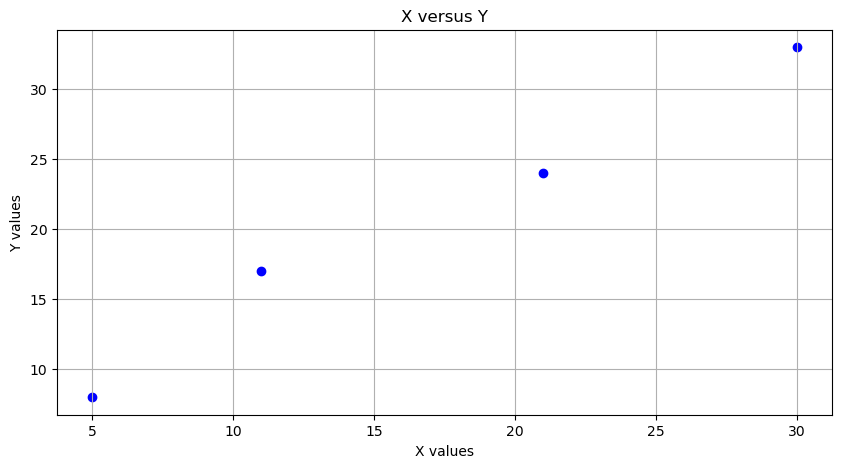

In [23]:
plt.figure(figsize=(10, 5))
plt.scatter(x=df['x'], y=df['y'], color='blue')
plt.title("X versus Y")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.grid(True)
plt.show()

##### Correlation matrix

In [25]:
correlation_matrix = np.corrcoef(x, y)

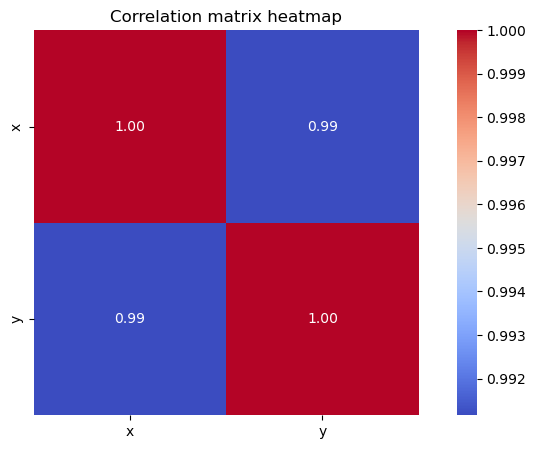

In [27]:
plt.figure(figsize=(10, 5))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            cbar=True,
            square=True,
            fmt='.2f',
            xticklabels=['x', 'y'],
            yticklabels=['x', 'y'])
plt.title("Correlation matrix heatmap")
plt.show()

###### Code inspired by [this video](https://www.youtube.com/watch?v=gQGYzZRN3EM&list=PLcQVY5V2UY4LF-eHg0tfTpWHhgpX9XF4S&index=10)